# Phase 0 — Twitter Financial News Sentiment EDA

Reproducible companion to [`reports/phase0-eda.md`](../reports/phase0-eda.md).
Run top-to-bottom on a fresh `uv sync`.

Plan: [`plans/01-phase0-eda.md`](../plans/01-phase0-eda.md) (Revision 2).

## 1. Imports & dataset load

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

from finsense.data.splits import (
    HF_REPO_ID, LABELS, SEED, build_phase0_v1, load_split_indices,
)

ds = load_dataset(HF_REPO_ID)
ds

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

## 2. Canonical project splits

Load the persisted index lists and verify they round-trip with `build_phase0_v1`.

In [2]:
splits = load_split_indices()
rebuilt = build_phase0_v1(ds['train']['label'], len(ds['validation']))
assert splits == rebuilt, 'NON-DETERMINISTIC: persisted != rebuilt'
{name: len(ix) for name, ix in splits.items()}

{'train': 8588, 'val': 955, 'test': 2388}

## 3. Class distribution

Counts and proportions for our `train` / `val` / `test` (renamed from HF `validation`).

In [3]:
y_hf_train = np.array(ds['train']['label'])
y_hf_val   = np.array(ds['validation']['label'])

y = {
    'train': y_hf_train[splits['train']],
    'val':   y_hf_train[splits['val']],
    'test':  y_hf_val[splits['test']],
}

rows = []
for name, arr in y.items():
    counts = np.bincount(arr, minlength=3)
    pct = counts / counts.sum() * 100
    rows.append({
        'split': name, 'n': int(counts.sum()),
        'Bearish': int(counts[0]), 'Bullish': int(counts[1]), 'Neutral': int(counts[2]),
        'Bearish %': round(pct[0], 2),
        'Bullish %': round(pct[1], 2),
        'Neutral %': round(pct[2], 2),
    })
dist_df = pd.DataFrame(rows).set_index('split')
dist_df

,n,Bearish,Bullish,Neutral,Bearish %,Bullish %,Neutral %
split,,,,,,,
train,8588,1298,1730,5560,15.11,20.14,64.74
val,955,144,193,618,15.08,20.21,64.71
test,2388,347,475,1566,14.53,19.89,65.58


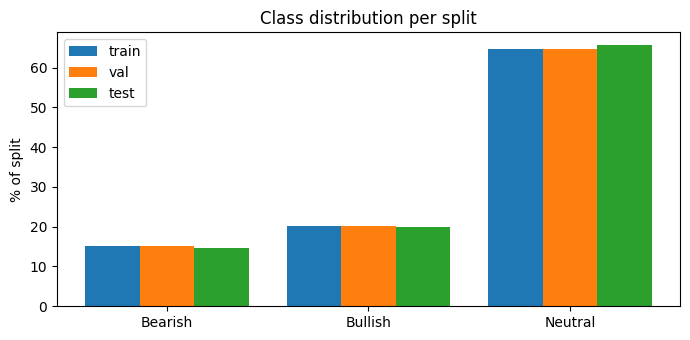

imbalance ratio (train, max/min): 4.284


In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
x = np.arange(3)
width = 0.27
for i, (name, arr) in enumerate(y.items()):
    counts = np.bincount(arr, minlength=3) / arr.size * 100
    ax.bar(x + (i - 1) * width, counts, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[i] for i in range(3)])
ax.set_ylabel('% of split')
ax.set_title('Class distribution per split')
ax.legend()
plt.tight_layout()
plt.show()

ratio = float(y['train'].max() if hasattr(y['train'], 'max') else None)
counts_train = np.bincount(y['train'], minlength=3)
print(f'imbalance ratio (train, max/min): {counts_train.max() / counts_train.min():.3f}')

## 4. Sequence-length distribution

Tokenized with `microsoft/deberta-v3-base` (Phase 1 backbone).

In [5]:
tok = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')

def lengths(texts):
    enc = tok(texts, add_special_tokens=True, truncation=False, padding=False)
    return np.array([len(ids) for ids in enc['input_ids']])

L = {
    'train': lengths([ds['train']['text'][i] for i in splits['train']]),
    'val':   lengths([ds['train']['text'][i] for i in splits['val']]),
    'test':  lengths(list(ds['validation']['text'])),
}

len_rows = []
for name, arr in L.items():
    len_rows.append({
        'split': name, 'n': int(arr.size),
        'min': int(arr.min()), 'p50': int(np.percentile(arr, 50)),
        'p95': int(np.percentile(arr, 95)), 'p99': int(np.percentile(arr, 99)),
        'max': int(arr.max()), 'mean': round(float(arr.mean()), 2),
        '> 64': round(float((arr > 64).mean()) * 100, 3),
        '> 96': round(float((arr > 96).mean()) * 100, 3),
        '> 128': round(float((arr > 128).mean()) * 100, 3),
    })
pd.DataFrame(len_rows).set_index('split')

,n,min,p50,p95,p99,max,mean,> 64,> 96,> 128
split,,,,,,,,,,
train,8588,3,24,50,56,92,26.88,0.210,0.0,0.0
val,955,3,24,49,54,79,26.23,0.105,0.0,0.0
test,2388,4,24,49,54,77,27.05,0.126,0.0,0.0


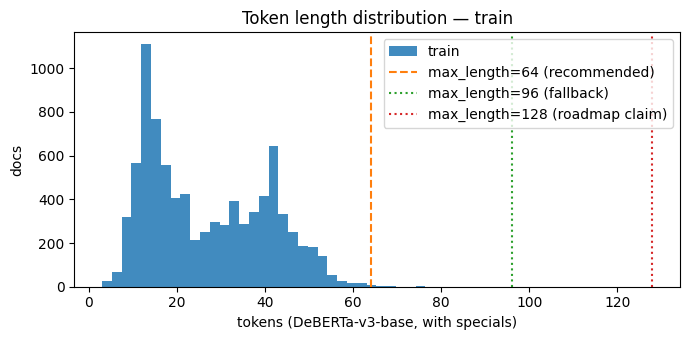

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(L['train'], bins=40, alpha=0.85, label='train')
ax.axvline(64,  color='C1', linestyle='--', label='max_length=64 (recommended)')
ax.axvline(96,  color='C2', linestyle=':',  label='max_length=96 (fallback)')
ax.axvline(128, color='C3', linestyle=':',  label='max_length=128 (roadmap claim)')
ax.set_xlabel('tokens (DeBERTa-v3-base, with specials)')
ax.set_ylabel('docs')
ax.set_title('Token length distribution — train')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Domain-specific tokens

Cashtags, hashtags, URLs, mentions — counted on the FinSense `train` split.

In [7]:
CASHTAG = re.compile(r'\$([A-Za-z][A-Za-z0-9._-]{0,9})')
HASHTAG = re.compile(r'#([A-Za-z][A-Za-z0-9_]{0,30})')
URL     = re.compile(r'https?://\S+')
MENTION = re.compile(r'(?<![A-Za-z0-9_])@([A-Za-z0-9_]{1,15})')

texts = [ds['train']['text'][i] for i in splits['train']]
cashtags, hashtags, mentions = Counter(), Counter(), Counter()
n_url = 0
docs_with = {'cashtag': 0, 'hashtag': 0, 'url': 0, 'mention': 0}
for t in texts:
    cs = CASHTAG.findall(t); hs = HASHTAG.findall(t)
    us = URL.findall(t);     ms = MENTION.findall(t)
    cashtags.update(c.upper() for c in cs)
    hashtags.update(h.lower() for h in hs)
    n_url += len(us)
    mentions.update(m.lower() for m in ms)
    if cs: docs_with['cashtag'] += 1
    if hs: docs_with['hashtag'] += 1
    if us: docs_with['url']     += 1
    if ms: docs_with['mention'] += 1

n = len(texts)
pd.DataFrame([
    {'token': k, 'docs containing': v, '% of corpus': round(v/n*100, 2)}
    for k, v in docs_with.items()
]).set_index('token')

,docs containing,% of corpus
token,,
cashtag,1289,15.01
hashtag,810,9.43
url,4033,46.96
mention,268,3.12


In [8]:
def top_table(counter, k=20, prefix=''):
    return pd.DataFrame(
        [{'token': prefix + t, 'count': c} for t, c in counter.most_common(k)]
    )

print('Top-20 cashtags')
display(top_table(cashtags, 20, '$'))
print('Top-20 hashtags')
display(top_table(hashtags, 20, '#'))
print('Top-10 mentions')
display(top_table(mentions, 10, '@'))

Top-20 cashtags


,token,count
0,$SPY,24
1,$TSLA,18
2,$COMDX,18
3,$SUMRX,13
4,$SCANX,13
5,$NVDA,12
6,$USO,12
7,$MDCO,11
8,$UBER,10
9,$AAPL,9


Top-20 hashtags


,token,count
0,#marketscreener,439
1,#stock,349
2,#economy,197
3,#markets,71
4,#finance,71
5,#trading,70
6,#stocks,66
7,#business,61
8,#investing,60
9,#stockmarket,54


Top-10 mentions


,token,count
0,@business,14
1,@cnbcmakeit,12
2,@bopinion,10
3,@jimcramer,9
4,@bw,6
5,@tradingnation,6
6,@bcheungz,5
7,@cmegroup,5
8,@heidi_chung,5
9,@rickjnewman,5


## 6. Findings — see the report for the full writeup

- Class imbalance ratio ≈ **4.28** on train (moderate, not severe).
- Stratification preserves class proportions to <0.1% across train/val.
- DeBERTa-v3 token length: max=92, p99=56 → **`max_length=64` covers 99.79% of train**.
- URLs are present in ~47% of tweets and carry no signal — Phase 1 should ablate stripping.
- `#marketscreener` dominates the hashtag distribution (439 of 1,978).
- Imbalance shortlist for Phase 1: **class-weighted CE**, **focal loss**, **WeightedRandomSampler**.

Full rationale and the metric / strategy schema live in
[`reports/phase0-eda.md`](../reports/phase0-eda.md).